# Load the data

In [1]:
import pandas as pd

df_wave1 = pd.read_csv(wave1_data, sep='\t', header=0, low_memory=False)
df_wave3 = pd.read_csv(wave3_data, sep='\t', header=0, low_memory=False)
df_wave4 = pd.read_csv(wave4_data, sep='\t', header=0, low_memory=False)

# Retrieve depression items from Wave 3
depression_items = [f'H3SP{i}' for i in range(5, 14)]

# Wave 1 variables to include as trauma
wave1_vars = ['H1CO10', 'H1FV3', 'H1FV4', 'H1FV6', 'H1SU5', 'H1SU7']

# Merge on respondent ID
id_cols = ['AID']
df_a = pd.merge(
    df_wave1[wave1_vars + id_cols],
    df_wave4[id_cols],
    on=id_cols,
    how='inner'
)

df = pd.merge(
    df_a,
    df_wave3[depression_items + id_cols],
    on=id_cols,
    how='inner'
)

## Clean up

In [2]:
# Recode 7s to 0s
df[wave1_vars] = df[wave1_vars].replace(7, 0).replace('7', 0)

# Convert to numeric (coerces invalid to NaN)
for var in wave1_vars:
    df[var] = pd.to_numeric(df[var], errors='coerce')

# Drop participants with 6, 8, OR NaN in ANY wave1_vars
initial_n = len(df)
mask_keep = ~(df[wave1_vars].isin([6, 8]).any(axis=1) | df[wave1_vars].isna().any(axis=1))
df = df[mask_keep].copy()

print(f"Sample size before filtering: {initial_n}")
print(f"Sample size after filtering 6s/8s/NaNs: {len(df)}")
print(f"Participants dropped: {initial_n - len(df)}")

print("\nFinal value counts (no 6s, 8s, or NaNs):")
for col in wave1_vars:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


Sample size before filtering: 4208
Sample size after filtering 6s/8s/NaNs: 4182
Participants dropped: 26

Final value counts (no 6s, 8s, or NaNs):

H1CO10:
H1CO10
0.0    3981
1.0     201
Name: count, dtype: int64

H1FV3:
H1FV3
0    4138
1      36
2       8
Name: count, dtype: int64

H1FV4:
H1FV4
0    4003
1     162
2      17
Name: count, dtype: int64

H1FV6:
H1FV6
0    3749
1     337
2      96
Name: count, dtype: int64

H1SU5:
H1SU5
0    4071
1     111
Name: count, dtype: int64

H1SU7:
H1SU7
0    4140
1      42
Name: count, dtype: int64


## Reverse-score depression items

In [3]:
import numpy as np
reverse_items = ['H3SP7', 'H3SP11']

# Function to reverse score (0-3 scale, preserve 6/8 missing)
def reverse_score(series):
    return np.where(
        (series <= 4),    
        4 - series,        
        series             
    )

# Apply reverse scoring
for item in reverse_items:
    if item in df.columns:
        df[item] = reverse_score(df[item])
        print(f"Reverse-scored {item}")
    else:
        print(f"Warning: {item} not found")

# Drop participants with ANY 6 or 8 or 9 in depression items
mask_no_missing = ~(df[depression_items].isin([6, 8, 9]).any(axis=1))

df_clean = df[mask_no_missing].copy()

print(f"Original sample: {len(df)} participants")
print(f"After dropping 6/8/9 responses: {len(df_clean)} participants")
print(f"Participants dropped: {len(df) - len(df_clean)}")


Reverse-scored H3SP7
Reverse-scored H3SP11
Original sample: 4182 participants
After dropping 6/8/9 responses: 4160 participants
Participants dropped: 22


## Calculate Current Trauma Score

In [4]:
# Calculate cumulative trauma score from wave1_vars
df_clean['trauma_score'] = df_clean[wave1_vars].sum(axis=1)

# Add H4MAx Trauma Variables

In [5]:
# Mistreatment variables
mistreat_vars = ['H4MA1', 'H4MA3', 'H4MA5']


# Merge on respondent ID - store result in df_clean
id_cols = ['AID']
df_clean = pd.merge(df_clean, 
                    df_wave4[mistreat_vars + id_cols], 
                    on=id_cols, how='left')

# Now check what columns exist
print(f"Columns after merge: {list(df_clean.columns)}")

# Drop participants with NaN in H4MA1, H4MA3, H4MA5
df_clean = df_clean.dropna(subset=['H4MA1', 'H4MA3', 'H4MA5'])

print(f"After dropping NaN in H4MAx: {len(df_clean)}")

# Drop people with 96 or 98 in ANY H4MA variable
mask_no_refusals = ~df_clean[mistreat_vars].isin([96, 98]).any(axis=1)
df_clean = df_clean[mask_no_refusals].copy()

print(f"After dropping 96/98: {len(df_clean)}")

# Verify no 96/98 remain
print("\nCheck for refusals remaining:")
print(df_clean[mistreat_vars].isin([96, 98]).sum())

Columns after merge: ['H1CO10', 'H1FV3', 'H1FV4', 'H1FV6', 'H1SU5', 'H1SU7', 'AID', 'H3SP5', 'H3SP6', 'H3SP7', 'H3SP8', 'H3SP9', 'H3SP10', 'H3SP11', 'H3SP12', 'H3SP13', 'trauma_score', 'H4MA1', 'H4MA3', 'H4MA5']
After dropping NaN in H4MAx: 4160
After dropping 96/98: 4077

Check for refusals remaining:
H4MA1    0
H4MA3    0
H4MA5    0
dtype: int64

trauma_score distribution in df_clean:


## Recode and add to Composite

In [6]:
# 6=never is coded as 0 for total calculation
for var in mistreat_vars:
    df_clean[var] = df_clean[var].replace(6, 0)

# Add mistreatment score to existing trauma_score
df_clean['trauma_score'] = df_clean['trauma_score'] + df_clean[mistreat_vars].sum(axis=1)

print(f"Updated trauma_score (added mistreatment items)")
print(f"\nNew trauma_score distribution:")
print(df_clean['trauma_score'].describe())

# Check distribution of mistreat_vars
print("\n" + "="*55)
print("MISTREATMENT VARIABLE DISTRIBUTIONS")
print("="*55)

for var in mistreat_vars:
    counts = df_clean[var].value_counts().sort_index()
    props  = df_clean[var].value_counts(normalize=True).sort_index() * 100

    print(f"\n{var}")
    print(f"  {'Value':<10} {'N':>8} {'%':>8}")
    print(f"  {'-'*28}")
    for val in counts.index:
        print(f"  {int(val):<10} {int(counts[val]):>8} {props[val]:>7.1f}%")
    print(f"  {'-'*28}")
    print(f"  {'Total':<10} {int(counts.sum()):>8} {'100.0%':>8}")
    print(f"  Mean:   {df_clean[var].mean():.3f}")
    print(f"  Median: {df_clean[var].median():.1f}")
    print(f"  SD:     {df_clean[var].std():.3f}")
    print(f"  Range:  {int(df_clean[var].min())} – {int(df_clean[var].max())}")


display(df_clean)

Updated trauma_score (added mistreatment items)

New trauma_score distribution:
count    4077.000000
mean        2.238901
std         2.991126
min         0.000000
25%         0.000000
50%         1.000000
75%         3.000000
max        18.000000
Name: trauma_score, dtype: float64

MISTREATMENT VARIABLE DISTRIBUTIONS

H4MA1
  Value             N        %
  ----------------------------
  0              2186    53.6%
  1               418    10.3%
  2               387     9.5%
  3               418    10.3%
  4               180     4.4%
  5               488    12.0%
  ----------------------------
  Total          4077   100.0%
  Mean:   1.375
  Median: 0.0
  SD:     1.793
  Range:  0 – 5

H4MA3
  Value             N        %
  ----------------------------
  0              3405    83.5%
  1               184     4.5%
  2               131     3.2%
  3               127     3.1%
  4                68     1.7%
  5               162     4.0%
  ----------------------------
  Total        

,H1CO10,H1FV3,H1FV4,H1FV6,H1SU5,H1SU7,AID,H3SP5,H3SP6,H3SP7,H3SP8,H3SP9,H3SP10,H3SP11,H3SP12,H3SP13,trauma_score,H4MA1,H4MA3,H4MA5
0,0.0,0,0,0,0,0,57101310,3,1,1,2,1,1,3,1,0,0.0,0,0,0
1,0.0,0,0,1,0,0,57103869,0,0,1,0,0,0,1,0,0,8.0,1,5,1
2,0.0,0,0,0,0,0,57109625,1,1,1,0,0,0,2,0,0,4.0,0,4,0
3,0.0,0,0,0,0,0,57111071,0,0,1,0,0,0,1,0,0,0.0,0,0,0
4,0.0,0,0,0,0,0,57113943,0,0,1,0,0,1,1,0,0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4154,0.0,0,0,0,0,0,99718925,0,0,1,0,0,0,1,1,0,1.0,1,0,0
4156,0.0,0,0,0,0,0,99719378,0,0,1,1,0,2,1,0,0,6.0,3,3,0
4157,0.0,0,0,0,0,0,99719930,0,1,1,0,1,1,1,1,1,0.0,0,0,0
4158,0.0,0,0,0,0,0,99719939,0,3,1,1,0,0,1,0,0,0.0,0,0,0


# Bootstrapped Correlation Analysis
**NOTE:** Calculating raw correlations may not be methodologically appropriate. These correlation matrices were **not** used for network analysis and heatmaps were excluded from final analysis. This part of the code can be **disregarded**, it is only retained here because it creates the trauma groups and calculates mean depression scores. 

Trauma score range: 0.0 – 18.0
Percentiles: 25th=0.0, 50th=1.0, 75th=3.0, 85th=5.0
Using 75th percentile as high split: 3.0
Final bin edges: [-0.001, 1.0, 2.0, 3.0, 18.001]  →  labels: ['No', 'Low', 'Medium', 'High']

Trauma score distribution:
count    4077.000000
mean        2.238901
std         2.991126
min         0.000000
25%         0.000000
50%         1.000000
75%         3.000000
max        18.000000
Name: trauma_score, dtype: float64

Participants per bin:
trauma_bin
No        1754
Low        544
Medium     424
High      1355
Name: count, dtype: int64

Fraction in each bin:
trauma_bin
No        0.430
Low       0.133
Medium    0.104
High      0.332
Name: count, dtype: float64

Depression score computed from 9 items: ['H3SP5', 'H3SP6', 'H3SP7', 'H3SP8', 'H3SP9', 'H3SP10', 'H3SP11', 'H3SP12', 'H3SP13']
count    4077.000
mean        6.442
std         4.018
min         2.000
25%         3.000
50%         5.000
75%         8.000
max        27.000
Name: depression_score, dtype: floa

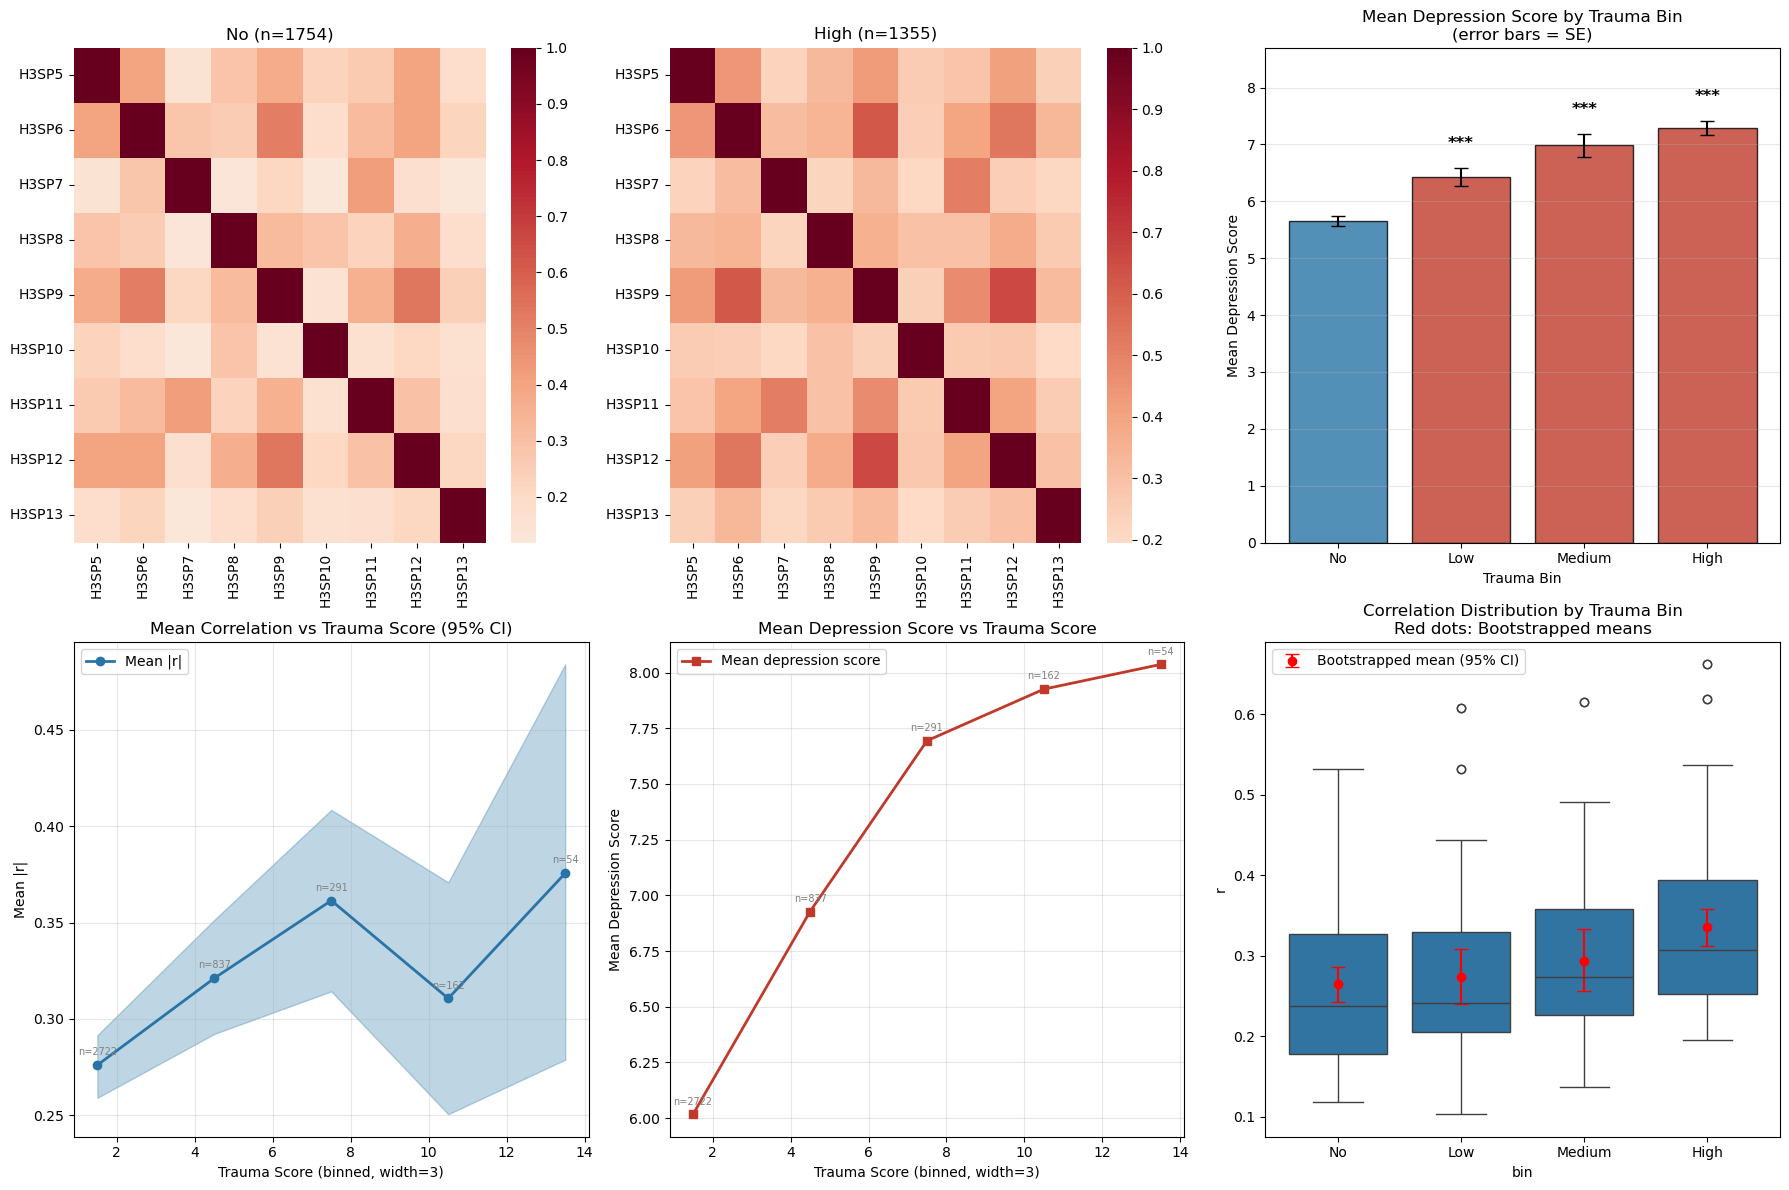

In [8]:
from scipy.stats import mannwhitneyu
import seaborn as sns
import matplotlib.pyplot as plt


# == Binning ==============================================================
# Use min, max, and quartiles to determine cut-offs (85% not used in the
# final analysis, was previously used as safeguard)
score_min  = df_clean['trauma_score'].min()
perc_25    = df_clean['trauma_score'].quantile(0.25)
perc_50    = df_clean['trauma_score'].quantile(0.50)
perc_75    = df_clean['trauma_score'].quantile(0.75)
perc_85    = df_clean['trauma_score'].quantile(0.85)
score_max  = df_clean['trauma_score'].max()

print(f"Trauma score range: {score_min} – {score_max}")
print(f"Percentiles: 25th={perc_25}, 50th={perc_50}, 75th={perc_75}, 85th={perc_85}")

# 85% was used with a different dataset where 75th and 50th percentile had
# equal scores
if perc_75 > perc_50:
    perc_split = perc_75
    print(f"Using 75th percentile as high split: {perc_split}")
else:
    perc_split = perc_85
    print(f"75th percentile equals median, using 85th percentile: {perc_split}")

raw_edges = [score_min, perc_25, perc_50, perc_split, score_max]
fixed_edges = [round(float(raw_edges[0]), 4)]
for e in raw_edges[1:]:
    e = round(float(e), 4)
    if e > fixed_edges[-1]:
        fixed_edges.append(e)
    else:
        bumped = fixed_edges[-1] + 1
        print(f"Warning: edge {e} not > {fixed_edges[-1]}, bumped to {bumped}")
        fixed_edges.append(bumped)

fixed_edges[0] = fixed_edges[0] - 0.001
fixed_edges[-1] = fixed_edges[-1] + 0.001

n_bins = len(fixed_edges) - 1
labels = ['No', 'Low', 'Medium', 'High'][:n_bins]
print(f"Final bin edges: {fixed_edges}  →  labels: {labels}")

df_clean['trauma_bin'] = pd.cut(df_clean['trauma_score'],
                                 bins=fixed_edges,
                                 labels=labels,
                                 duplicates='drop',
                                 right = False)

print("\nTrauma score distribution:")
print(df_clean['trauma_score'].describe())
print("\nParticipants per bin:")
print(df_clean['trauma_bin'].value_counts().sort_index())
print("\nFraction in each bin:")
print((df_clean['trauma_bin'].value_counts().sort_index() / len(df_clean)).round(3))


# == Compute depression total score from items ==================================
df_clean['depression_score'] = df_clean[depression_items].sum(axis=1)
print(f"\nDepression score computed from {len(depression_items)} items: {depression_items}")
print(df_clean['depression_score'].describe().round(3))


# == Depression score per bin + Mann-Whitney vs No ==============================
print("\n=== DEPRESSION SCORE BY TRAUMA BIN ===")
existing_bins = list(df_clean['trauma_bin'].cat.categories)
no_dep = df_clean[df_clean['trauma_bin'] == 'No']['depression_score']

dep_summary = []
for bin_name in existing_bins:
    bin_data = df_clean[df_clean['trauma_bin'] == bin_name]['depression_score']
    if len(bin_data) > 10:
        row = {
            'bin':    bin_name,
            'n':      len(bin_data),
            'mean':   bin_data.mean(),
            'median': bin_data.median(),
            'sd':     bin_data.std(),
        }
        if bin_name != 'No':
            stat, p = mannwhitneyu(bin_data, no_dep, alternative='two-sided')
            n1, n2  = len(bin_data), len(no_dep)
            r_rb    = 1 - (2 * stat) / (n1 * n2)
            row['U']        = stat
            row['p_vs_no'] = p
            row['r_rb']     = r_rb
        else:
            row['U']        = np.nan
            row['p_vs_no'] = np.nan
            row['r_rb']     = np.nan
        dep_summary.append(row)

dep_df = pd.DataFrame(dep_summary).set_index('bin')
print(dep_df.round(4).to_string())

print("\nNote: p_vs_no = Mann-Whitney U test vs No Trauma bin (two-sided)")
print("      r_rb = rank-biserial correlation (effect size; |r| > .1 small, > .3 medium, > .5 large)")


# == Helper ====================================================================
def corr_stats(group_df, items):
    corr_matrix  = group_df[items].corr(method='spearman')
    offdiag      = corr_matrix.stack().abs()
    offdiag      = offdiag[offdiag < 1]
    strong_count = ((corr_matrix.abs() > 0.3).sum().sum() - len(items)) // 2
    return {'mean_r': offdiag.mean(), 'sd_r': offdiag.std(),
            'n_strong': strong_count, 'n_pairs': len(offdiag)}


# == Bootstrapping =============================================================
def bootstrap_bin_stats(df, bin_col, items, n_bootstrap=1000, ci=0.95):
    results = {}
    alpha   = 1 - ci
    for bin_name in df[bin_col].cat.categories:
        bin_data = df[df[bin_col] == bin_name]
        if len(bin_data) <= 10:
            continue
        boot_means, boot_sds, boot_nstrong = [], [], []
        for _ in range(n_bootstrap):
            s = corr_stats(bin_data.sample(n=len(bin_data), replace=True), items)
            boot_means.append(s['mean_r'])
            boot_sds.append(s['sd_r'])
            boot_nstrong.append(s['n_strong'])
        results[bin_name] = {
            'n_participants': len(bin_data),
            'mean_r':         np.mean(boot_means),
            'mean_r_ci':      (np.percentile(boot_means, 100*alpha/2),
                               np.percentile(boot_means, 100*(1-alpha/2))),
            'sd_r':           np.mean(boot_sds),
            'sd_r_ci':        (np.percentile(boot_sds, 100*alpha/2),
                               np.percentile(boot_sds, 100*(1-alpha/2))),
            'n_strong_mean':  np.mean(boot_nstrong),
            'n_strong_ci':    tuple(np.percentile(boot_nstrong,
                                                   [100*alpha/2, 100*(1-alpha/2)]))
        }
    return results

boot_stats = bootstrap_bin_stats(df_clean, 'trauma_bin', depression_items, n_bootstrap=1000)

print("\n=== BOOTSTRAPPED CORRELATION STATS BY TRAUMA BIN (95% CI) ===")
for bin_name, s in boot_stats.items():
    print(f"\n{bin_name} (n={s['n_participants']}):")
    print(f"  Mean |r|: {s['mean_r']:.3f} [{s['mean_r_ci'][0]:.3f}, {s['mean_r_ci'][1]:.3f}]")
    print(f"  SD |r|:   {s['sd_r']:.3f} [{s['sd_r_ci'][0]:.3f}, {s['sd_r_ci'][1]:.3f}]")
    print(f"  Strong corrs (>0.3): {s['n_strong_mean']:.1f} "
          f"[{s['n_strong_ci'][0]:.1f}, {s['n_strong_ci'][1]:.1f}]")

# Point estimates
orig_stats = {}
for bin_name in df_clean['trauma_bin'].cat.categories:
    bin_data = df_clean[df_clean['trauma_bin'] == bin_name]
    if len(bin_data) > 10:
        s = corr_stats(bin_data, depression_items)
        s['n_participants'] = len(bin_data)
        orig_stats[bin_name] = s

print("\n=== ORIGINAL POINT ESTIMATES ===")
print(pd.DataFrame(orig_stats).T.round(3))


# == offdiag_df ===================================================================
all_offdiags, bin_labels_list = [], []
for bin_name in df_clean['trauma_bin'].cat.categories:
    bin_data = df_clean[df_clean['trauma_bin'] == bin_name]
    if len(bin_data) > 10:
        corr_matrix = bin_data[depression_items].corr(method='spearman')
        offdiag     = corr_matrix.stack().abs()
        offdiag     = offdiag[offdiag < 1]
        all_offdiags.extend(offdiag)
        bin_labels_list.extend([bin_name] * len(offdiag))
offdiag_df = pd.DataFrame({'r': all_offdiags, 'bin': bin_labels_list})

existing_bins   = list(df_clean['trauma_bin'].cat.categories)
comparison_bins = [b for b in existing_bins if b != 'No']


# == Permutation tests vs No Trauma ===============================================
print("\n=== PERMUTATION TESTS vs No Trauma (two-tailed, n_perm=1000) ===")
no_data = df_clean[df_clean['trauma_bin'] == 'No']
if len(no_data) > 10:
    no_r = []
    for _ in range(1000):
        boot_sample = no_data.sample(n=len(no_data), replace=True)
        corr_matrix = boot_sample[depression_items].corr(method='spearman')
        offdiag     = corr_matrix.stack().abs()
        offdiag     = offdiag[offdiag < 1]
        no_r.extend(offdiag)

    for bin_name in comparison_bins:
        bin_data = df_clean[df_clean['trauma_bin'] == bin_name]
        if len(bin_data) > 10:
            bin_r = []
            for _ in range(1000):
                boot_sample = bin_data.sample(n=len(bin_data), replace=True)
                corr_matrix = boot_sample[depression_items].corr(method='spearman')
                offdiag     = corr_matrix.stack().abs()
                offdiag     = offdiag[offdiag < 1]
                bin_r.extend(offdiag)

            combined   = np.array(no_r + bin_r)
            obs_diff   = np.mean(bin_r) - np.mean(no_r)
            perm_diffs = []
            for _ in range(1000):
                np.random.shuffle(combined)
                split = len(no_r)
                perm_diffs.append(np.mean(combined[split:]) - np.mean(combined[:split]))

            p_value = np.mean(np.abs(np.array(perm_diffs)) >= np.abs(obs_diff))
            print(f"{bin_name} vs No: obs_diff={obs_diff:.4f}, p={p_value:.4f}")


# == Plots =======================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

no_data     = df_clean[df_clean['trauma_bin'] == 'No']
highest_bin  = [b for b in existing_bins if b in ['Medium', 'High']]
highest_bin  = highest_bin[-1] if highest_bin else existing_bins[-1]
highest_data = df_clean[df_clean['trauma_bin'] == highest_bin]

# Heatmaps
sns.heatmap(no_data[depression_items].corr(method='spearman'),
            annot=False, cmap='RdBu_r', center=0, ax=axes[0, 0])
axes[0, 0].set_title(f'No (n={len(no_data)})')

if len(highest_data) > 10:
    sns.heatmap(highest_data[depression_items].corr(method='spearman'),
                annot=False, cmap='RdBu_r', center=0, ax=axes[0, 1])
    axes[0, 1].set_title(f'{highest_bin} (n={len(highest_data)})')
else:
    axes[0, 1].text(0.5, 0.5, f'{highest_bin}\n(n<10)',
                    ha='center', va='center', transform=axes[0, 1].transAxes)

# == Depression mean by bin =======================================================
bin_names  = dep_df.index.tolist()
bin_means  = dep_df['mean'].values
bin_sds    = dep_df['sd'].values
bin_ns     = dep_df['n'].values
bin_ses    = bin_sds / np.sqrt(bin_ns)
p_vals     = dep_df['p_vs_no'].values

colors = ['#2874A6' if b == 'No' else '#C0392B' for b in bin_names]
bars = axes[0, 2].bar(bin_names, bin_means, yerr=bin_ses, capsize=5,
                       color=colors, alpha=0.8, edgecolor='black')
axes[0, 2].set_title('Mean Depression Score by Trauma Bin\n(error bars = SE)')
axes[0, 2].set_ylabel('Mean Depression Score')
axes[0, 2].set_xlabel('Trauma Bin')

y_max = max(bin_means) + max(bin_ses) * 2
for i, (bin_name, p) in enumerate(zip(bin_names, p_vals)):
    if pd.isna(p):
        continue
    if p < 0.001:
        sig = '***'
    elif p < 0.01:
        sig = '**'
    elif p < 0.05:
        sig = '*'
    else:
        sig = 'ns'
    axes[0, 2].text(i, bin_means[i] + bin_ses[i] + 0.3, sig,
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[0, 2].set_ylim(0, y_max + 1)
axes[0, 2].grid(True, alpha=0.3, axis='y')

# == Trauma score vs mean |r| =======================================================
bin_width     = 3
score_min_int = int(df_clean['trauma_score'].min())
score_max_int = int(df_clean['trauma_score'].max())

score_corr, score_ci_no, score_ci_high, score_centers, score_ns = [], [], [], [], []
score_dep_means = []

for start in range(score_min_int, score_max_int, bin_width):
    end        = start + bin_width
    mask       = (df_clean['trauma_score'] >= start) & (df_clean['trauma_score'] < end)
    score_data = df_clean[mask]
    if len(score_data) > 10:
        boot_means = [
            corr_stats(score_data.sample(n=len(score_data), replace=True),
                       depression_items)['mean_r']
            for _ in range(500)
        ]
        score_corr.append(np.mean(boot_means))
        score_ci_no.append(np.percentile(boot_means, 2.5))
        score_ci_high.append(np.percentile(boot_means, 97.5))
        score_centers.append(start + bin_width / 2)
        score_ns.append(len(score_data))
        score_dep_means.append(score_data['depression_score'].mean())

if score_corr:
    axes[1, 0].plot(score_centers, score_corr, 'o-', linewidth=2, label='Mean |r|', color='#2874A6')
    axes[1, 0].fill_between(score_centers, score_ci_no, score_ci_high, alpha=0.3, color='#2874A6')
    for xc, yc, n in zip(score_centers, score_corr, score_ns):
        axes[1, 0].annotate(f'n={n}', xy=(xc, yc), textcoords='offset points',
                            xytext=(0, 7), ha='center', fontsize=7, color='grey')
    axes[1, 0].set_xlabel('Trauma Score (binned, width=3)')
    axes[1, 0].set_ylabel('Mean |r|')
    axes[1, 0].legend()
axes[1, 0].set_title('Mean Correlation vs Trauma Score (95% CI)')
axes[1, 0].grid(True, alpha=0.3)

# == Depression mean vs trauma score ============================================
if score_dep_means:
    axes[1, 1].plot(score_centers, score_dep_means, 's-', linewidth=2,
                    color='#C0392B', label='Mean depression score')
    for xc, yc, n in zip(score_centers, score_dep_means, score_ns):
        axes[1, 1].annotate(f'n={n}', xy=(xc, yc), textcoords='offset points',
                            xytext=(0, 7), ha='center', fontsize=7, color='grey')
    axes[1, 1].set_xlabel('Trauma Score (binned, width=3)')
    axes[1, 1].set_ylabel('Mean Depression Score')
    axes[1, 1].set_title('Mean Depression Score vs Trauma Score')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

# == Boxplot with bootstrapped means ============================================
bins_list = list(boot_stats.keys())
if bins_list:
    means    = [boot_stats[b]['mean_r']       for b in bins_list]
    ci_nos  = [boot_stats[b]['mean_r_ci'][0] for b in bins_list]
    ci_highs = [boot_stats[b]['mean_r_ci'][1] for b in bins_list]
    sns.boxplot(data=offdiag_df, x='bin', y='r', ax=axes[1, 2])
    axes[1, 2].errorbar(range(len(bins_list)), means,
                        yerr=[np.array(means) - np.array(ci_nos),
                               np.array(ci_highs) - np.array(means)],
                        fmt='o', capsize=5, color='red',
                        label='Bootstrapped mean (95% CI)')
    axes[1, 2].set_title('Correlation Distribution by Trauma Bin\nRed dots: Bootstrapped means')
    axes[1, 2].legend()

plt.tight_layout()
plt.show()


# Extract No & High Trauma Groups

In [9]:
# Extract No and High trauma groups into separate DataFrames
no_trauma_df = df_clean[df_clean['trauma_bin'] == 'No'].copy()
high_trauma_df = df_clean[df_clean['trauma_bin'] == 'High'].copy()

print(f"No trauma DataFrame: {len(no_trauma_df)} participants")
print(f"High trauma DataFrame: {len(high_trauma_df)} participants")

# Columns to drop from both dataframes
cols_to_drop = mistreat_vars + wave1_vars + ['AID', 'trauma_score', 'trauma_bin', 'depression_score']

# Drop columns from both dataframes
no_trauma_df = no_trauma_df.drop(columns=cols_to_drop)
high_trauma_df = high_trauma_df.drop(columns=cols_to_drop)

print(f"\nDropped {len(cols_to_drop)} columns from both dataframes")
print(f"No trauma DataFrame now has {len(no_trauma_df.columns)} columns")
print(f"High trauma DataFrame now has {len(high_trauma_df.columns)} columns")
print(f"\nRemaining columns in No trauma DF: {list(no_trauma_df.columns)}")
print(f"\nRemaining columns in High trauma DF: {list(high_trauma_df.columns)}")

# Save both dataframes to CSV files
no_trauma_df.to_csv('no_trauma_final.csv', index=False)
high_trauma_df.to_csv('high_trauma_final.csv', index=False)

print("\n=== DATAFRAMES SAVED ===")


No trauma DataFrame: 1754 participants
High trauma DataFrame: 1355 participants

Dropped 13 columns from both dataframes
No trauma DataFrame now has 9 columns
High trauma DataFrame now has 9 columns

Remaining columns in No trauma DF: ['H3SP5', 'H3SP6', 'H3SP7', 'H3SP8', 'H3SP9', 'H3SP10', 'H3SP11', 'H3SP12', 'H3SP13']

Remaining columns in High trauma DF: ['H3SP5', 'H3SP6', 'H3SP7', 'H3SP8', 'H3SP9', 'H3SP10', 'H3SP11', 'H3SP12', 'H3SP13']

=== DATAFRAMES SAVED ===
